#### Download datasets
##### download SberSQuAD

In [25]:
import pandas as pd
df1 = pd.read_json('./raw_datasets/sberquad/sberquad_train.json')
df2 = pd.read_json('./raw_datasets/sberquad/sberquad_test.json')
df3 = pd.read_json('./raw_datasets/sberquad/sberquad_valid.json')

sbersquad_df = pd.concat([df1, df2, df3], ignore_index=True)   
sbersquad_df['answer'] = sbersquad_df["answers"].apply(lambda x: x["text"][0])
sbersquad_df = sbersquad_df[["context", "question", "answer"]].copy()

no_answ_df = sbersquad_df[sbersquad_df["answer"]==''].copy()
no_answ_df = no_answ_df.drop_duplicates(subset="context", keep="first").copy()

sbersquad_df = sbersquad_df[sbersquad_df["answer"]!=''].copy()
sbersquad_df

,context,question,answer
0,В протерозойских отложениях органические остат...,чем представлены органические остатки?,известковыми выделениями сине-зелёных водорослей
1,В протерозойских отложениях органические остат...,что найдено в кремнистых сланцах железорудной ...,"нитевидные водоросли, грибные нити"
2,В протерозойских отложениях органические остат...,что встречается в протерозойских отложениях?,органические остатки
3,В протерозойских отложениях органические остат...,что относится к числу древнейших растительных ...,скопления графито-углистого вещества
4,В протерозойских отложениях органические остат...,как образовалось графито-углистое вещество?,в результате разложения Corycium enigmaticum
...,...,...,...
74295,Классическая трёхуровневая система накачки раб...,Где используется классическая трёхуровневая си...,в рубиновом лазере.
74296,Первая платёжная карта American Express появил...,какой инвестиционный банк входил в состав Amer...,Lehman Brothers
74297,Следующий альбом Heroes был во многом созвучен...,С каким альбомом был созвучен альбом Дэвида Бо...,Low
74298,"Одним из тех, на кого игра Данна произвела неи...",В каком техасском оркестре выступал гитарист Л...,Light Crust Doughboys


In [26]:
no_answ_df

,context,question,answer
45328,Многоклеточный организм — внесистематическая к...,У каких организмов отсутствуют настоящие диффе...,
45341,Акционерное общество открытого типа АКБ „Моско...,Когда была получена лицензия на осуществление ...,
45346,Однако не лишён этот язык и недостатков: так у...,"В какой среде рожденный, он стимулирует соотве...",
45355,Даже простая убеждённость в чём-либо на основе...,На основе чего простая убеждённость в чём-либо...,
45360,"Транспорт — густая сеть железных дорог, морско...",Какие украшения характерны для конька крыши фл...,
...,...,...,...
69239,В СССР серийно выпускались тепловозы ТЭ1 (1000...,Какая мощность была у серийно выпущенных тепло...,
69244,Мясо собаки являлось традиционным пищевым прод...,"Куда в Азии, согласно кулинарным традициям, по...",
69249,При написании Германии и этнографическо-геогра...,Каким является вопрос о роли личного опыта в о...,
69254,Банк ВТБ является головной структурой Группы В...,Где находятся дочерние и ассоциированные банки...,


##### Download WikiOmnia

In [3]:
from datasets import load_dataset

wo1_df = load_dataset(
    "json",
    data_files={
        "train": "https://huggingface.co/datasets/RussianNLP/wikiomnia/resolve/main/dummy/wikiomnia_ruT5_filtered/wikiomnia_ruT5_filtered_train.json"
    }
)["train"].to_pandas()

wo2_df = load_dataset(
    "json",
    data_files={
        "train": "https://huggingface.co/datasets/RussianNLP/wikiomnia/resolve/main/dummy/wikiomnia_ruGPT3_filtered/wikiomnia_ruGPT_3_filtered_train.json"
    }
)["train"].to_pandas()

wo3_df = load_dataset(
    "json",
    data_files={
        "train": "https://huggingface.co/datasets/RussianNLP/wikiomnia/resolve/main/dummy/wikiomnia_ruT5_raw/wikiomnia_dev.json"
    }
)["train"].to_pandas()

wo4_df = load_dataset(
    "json",
    data_files={
        "train": "https://huggingface.co/datasets/RussianNLP/wikiomnia/resolve/main/dummy/wikiomnia_ruT5_raw/wikiomnia_test.json"
    }
)["train"].to_pandas()

#### Prepare main dataset

In [ ]:
import re, pandas as pd
pd.reset_option("display.max_colwidth")

def repetition_score(text):
    text = re.sub(r'[^a-zа-яё0-9 ]', ' ', text.lower()).split()
    return len(set(text)) / len(text)

# ---- concat raw datasets ----
wo_df = pd.concat([wo1_df, wo2_df, wo3_df, wo4_df], ignore_index=True)   
wo_df = wo_df[["summary", "question", "answer",]].rename(
    columns={"summary": "context"}
)
full_df = pd.concat([wo_df, sbersquad_df], ignore_index=True)

# ---- drop deduplicates ----
full_df["answer_lower"] = full_df["answer"].str.lower()
full_df = full_df.drop_duplicates(subset="answer_lower", keep="first").copy()
full_df["question_lower"] = full_df["question"].str.lower()
full_df = full_df.drop_duplicates(subset="question_lower", keep="first").copy()
full_df = full_df.drop(columns=["answer_lower", "question_lower"]).copy()

# ---- drop short sentences ----
min_cont_len = 240
full_df = full_df[full_df["answer"].fillna("").str.len() > 45]
full_df = full_df[full_df["context"].str.len() > min_cont_len]
full_df = full_df[(full_df["answer"].str.len() / full_df["context"].str.len()) < 0.8]

# drop short sentences in no answer data
no_answ_df = no_answ_df[no_answ_df["context"].str.len() > min_cont_len]

# ---- drop context with formula like {...} ---- 
pattern = r"[{}]"
mask = full_df['context'].str.contains(pattern, regex=True, na=False)
full_df = full_df[~mask].copy()

# drop formula in no answer dataset
mask = no_answ_df['context'].str.contains(pattern, regex=True, na=False)
no_answ_df = no_answ_df[~mask].copy()

# ---- drop context with list of source ----
pattern = r"//[^//]+//"
mask = full_df['context'].str.contains(pattern, regex=True, na=False)
full_df = full_df[~mask].copy()

# drop context with list of source in no answer dataset
mask = no_answ_df['context'].str.contains(pattern, regex=True, na=False)
no_answ_df = no_answ_df[~mask].copy()

# ---- drop repetition text ---- 
threshold = 0.6
for col in ["context", "question", "answer"]:
    full_df = full_df[full_df[col].map(repetition_score) > threshold]

# drop repetition text in no answer dataset
no_answ_df = no_answ_df[no_answ_df['context'].map(repetition_score) > threshold]

full_df

In [28]:
no_answ_df

,context,question,answer
45328,Многоклеточный организм — внесистематическая к...,У каких организмов отсутствуют настоящие диффе...,
45341,Акционерное общество открытого типа АКБ „Моско...,Когда была получена лицензия на осуществление ...,
45346,Однако не лишён этот язык и недостатков: так у...,"В какой среде рожденный, он стимулирует соотве...",
45355,Даже простая убеждённость в чём-либо на основе...,На основе чего простая убеждённость в чём-либо...,
45360,"Транспорт — густая сеть железных дорог, морско...",Какие украшения характерны для конька крыши фл...,
...,...,...,...
69234,На основе прежней конфедерации телеских племён...,Какой года был последним годом существования С...,
69244,Мясо собаки являлось традиционным пищевым прод...,"Куда в Азии, согласно кулинарным традициям, по...",
69249,При написании Германии и этнографическо-геогра...,Каким является вопрос о роли личного опыта в о...,
69254,Банк ВТБ является головной структурой Группы В...,Где находятся дочерние и ассоциированные банки...,


#### Check repetition score and length distribution

In [6]:
print('\nContext repetition score:\n', full_df['context'].map(repetition_score).describe())
print('\nAnswers length:\n', full_df["answer"].str.len().describe())


Context repetition score:
 count    64210.000000
mean         0.835548
std          0.080802
min          0.600386
25%          0.781250
50%          0.839286
75%          0.894737
max          1.000000
Name: context, dtype: float64

Answers length:
 count    64210.000000
mean        63.600607
std         17.959608
min         46.000000
25%         51.000000
50%         58.000000
75%         71.000000
max        258.000000
Name: answer, dtype: float64


In [7]:
from pathlib import Path
import sys

proj_root = Path("..").resolve()    # Path().resolve().parent
if str(proj_root) not in sys.path:
    sys.path.append(str(proj_root))

#### Clean main dataset

In [ ]:
pd.set_option("display.max_colwidth", None)
from finetune.qa_cleaner import QACleaner
from tokenizer.bpe_tokenizer import BPETokenizer

bpe_tokenizer = BPETokenizer().from_file("../tokenizer/bpe_tokenizer_v2/tokenizer.json")
bpe_tokenizer.post_processor = None

cleaner = QACleaner(bpe_tokenizer)

full_df = cleaner.clean_df(full_df)
full_df

In [51]:
sampl = {
    "instruction": "Ответь используя только данный контекст.",
    "question": "Какие функции выполняет контроллинг затрат на продукт и как он помогает определить минимальную цену продажи продукта с учетом затрат?",
    "answer": "Контроллинг затрат на продукт в SAP позволяет вычислять совокупные затраты на производство или оказание услуг, анализировать их структуру и на основе этих данных определять минимальную цену реализации, при которой обеспечивается прибыльность продукта.",
    "positive_docs": [
      "Контроллинг затрат на продукт представляет собой важную функцию в системе SAP, которая позволяет вычислить затраты, возникшие при производстве продукта или предоставлении услуги. Эта функция обеспечивает прозрачность затрат на всех этапах создания продукта, начиная от закупки сырья и заканчивая выпуском готовой продукции. Полученные данные используются для анализа структуры затрат и выявления ключевых факторов, влияющих на себестоимость.",
      "С помощью контроллинга затрат на продукт можно определить минимальную цену, по которой продукт может быть реализован с прибылью. Это достигается путем сопоставления всех понесенных затрат с ожидаемой выручкой и анализа маржинальной прибыли. Такой подход позволяет принимать обоснованные управленческие решения, связанные с ценообразованием, оптимизацией затрат и выбором стратегии продаж.",
      "Дополнительно контроллинг затрат на продукт интегрируется с другими компонентами системы, включая учет затрат и учет результатов, что позволяет использовать единые данные для анализа. Это обеспечивает согласованность расчетов и исключает необходимость дополнительной сверки, поскольку все данные формируются на основе единых источников и используются для комплексной оценки эффективности деятельности."
    ],
    "negative_docs": [
      "Учет по видам затрат предоставляет обзор всех затрат и выручки, возникающих в организации, и позволяет классифицировать их по различным категориям. Он используется для анализа общей структуры расходов и доходов, но не фокусируется на расчете себестоимости конкретного продукта или определении его минимальной цены реализации.",
      "Учет по местам возникновения затрат отслеживает, где именно в организации формируются затраты, и помогает распределять косвенные расходы между подразделениями. Этот инструмент полезен для внутреннего контроля, однако он не предназначен для анализа полной себестоимости продукта или расчета его прибыльности.",
      "Внутренние заказы используются для накопления затрат по конкретным задачам или проектам, позволяя контролировать бюджет и отслеживать выполнение работ. Несмотря на их полезность для управления затратами, они не обеспечивают механизмов расчета минимальной цены продукта.",
      "Учет результатов ориентирован на анализ прибыли и убытков по сегментам рынка, таким как регионы, клиенты или продукты. Он помогает оценить эффективность продаж, но не занимается расчетом производственных затрат или определением себестоимости продукции.",
      "Место возникновения прибыли используется для анализа финансовых результатов отдельных подразделений и оценки их эффективности. Этот инструмент работает на статистической основе и не участвует в вычислении затрат на производство продукта.",
      "Балансовая единица представляет собой организационную структуру для внешней отчетности и используется для формирования бухгалтерских документов. Она не связана напрямую с расчетом себестоимости продукции или определением цен.",
      "Бизнес-сфера — внутренняя организационная единица, для которой можно формировать баланс и отчёт о прибылях и убытках в дополнение к балансовым единицам. При проводке первичных затрат на МВЗ система автоматически определяет бизнес-сферу из основных данных МВЗ — без ручного указания в документе. Если необходима внутренняя отчётность по бизнес-сферам, нужно выполнить ведение бизнес-сферы в CO: при создании МВЗ обязательно указывается соответствующая бизнес-сфера."
    ]
  }
len(bpe_tokenizer.encode("".join(sampl['positive_docs'] + sampl['negative_docs'])))

602

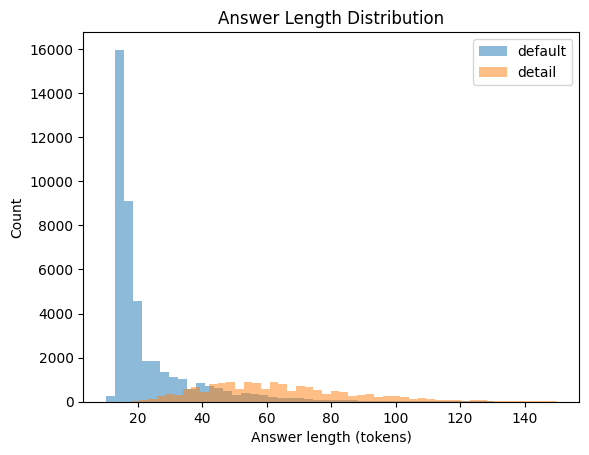

In [23]:
import matplotlib.pyplot as plt

def answer_len_distrib(df):
    default_answers_len = df.loc[
        df['instruction_type'] == 'default', 'answer'
    ].map(cleaner._encoded_text_len)

    detail_answers_len = df.loc[
        df['instruction_type'] == 'detail', 'answer'
    ].map(cleaner._encoded_text_len)

    plt.figure()
    plt.hist(default_answers_len, bins=50, alpha=0.5, label="default")
    plt.hist(detail_answers_len, bins=50, alpha=0.5, label="detail")

    plt.xlabel("Answer length (tokens)")
    plt.ylabel("Count")
    plt.title("Answer Length Distribution")
    plt.legend()
    plt.show()

answer_len_distrib(full_df)

# print('\nAnswers length:\n', full_df['answer'].map(cleaner._encoded_text_len).describe())

#### Clean no answers dataset 

In [29]:
from qa_instructions import pick_instruction
import numpy as np

# ---- remove accents and normalize ----
no_answ_df['context'] = no_answ_df['context'].map(cleaner.remove_accents).map(cleaner.normalize_text)   

# ---- length filter ----
no_answ_df["context_len"] = no_answ_df["context"].map(cleaner._encoded_text_len)
no_answ_df = no_answ_df[
    (no_answ_df["context_len"] > 150) & (no_answ_df["context_len"] < 300)
].copy()

# sample up to 3% no answers
n = int(0.03 * full_df.shape[0])
no_answ_df = no_answ_df.sample(n=min(n, len(no_answ_df)), random_state=42).copy()

# map instruction
no_answ_df["instruction_type"] = np.random.choice(
    ["default", "detail"],
    size=len(no_answ_df),
    p=[0.5, 0.5]    
)
no_answ_df["instruction"] = no_answ_df["instruction_type"].apply(pick_instruction)

no_answ_df

,context,question,answer,context_len,instruction_type,instruction
65365,Ведущая отрасль сельского хозяйства — растение...,Какая часть посевных площадей в Испании отведе...,,159,default,Ответь используя только данный контекст.
62809,Натаниэль Готорн и Эдгар По вошли в историю но...,За какие разработки принадлежит заслуга Эдгару...,,199,default,Ответь используя только данный контекст.
57602,Деревянистые плодовые тела состоят из плотно п...,Какие виды плодовых тел гриба однородны по про...,,176,default,Ответь используя только данный контекст.
58609,"Однако, несмотря на снижение популярности альт...",Из-за чего группа Radiohead достигла пика в св...,,187,detail,Дай детальный ответ только из этих документов.
49238,"Первоначально Гермес — фаллическое божество, и...",Что представляла собой Герма?,,151,detail,Дай детальный ответ только из этих документов.
...,...,...,...,...,...,...
50439,В 1218 году Чингисхан отправил в Хорезм посоль...,В каком году Чингисхан отправил в Хорезм посол...,,175,detail,Дай детальный ответ только из этих документов.
51628,В XVII веке тема противостояния с Римом более ...,Какие философы обращались в римскому историку ...,,282,default,Ответь используя только данный контекст.
58760,Количество пассажиров в метро зависит от време...,От чего зависит количество пассажиров?,,168,detail,Дай детальный ответ только из этих документов.
58623,Летом 1908 года жена Шёнберга Матильда оставил...,Какое свое новое изобретение Шёнберг применяет...,,156,default,Ответь используя только данный контекст.


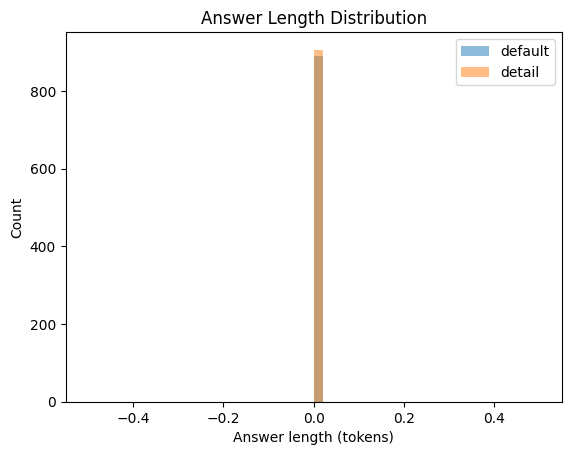

In [30]:
answer_len_distrib(no_answ_df)

#### Check instruction_type and tokens length distribution

In [31]:
print('Numbers of detail (TO DO):', int(cleaner.long_answ_ratio * full_df.shape[0]))
counts = full_df["instruction_type"].value_counts()
print(counts, '\ntotal =', counts.sum()) 
print('\nContext tokens length:\n', full_df["context"].map(cleaner._encoded_text_len).describe())
print('\nAnswers length:\n', full_df['answer'].map(cleaner._encoded_text_len).describe())

Numbers of detail (TO DO): 35923
instruction_type
default    43365
detail     16507
Name: count, dtype: int64 
total = 59872

Context tokens length:
 count    59872.000000
mean       157.898283
std        116.878148
min         31.000000
25%         78.000000
50%        123.000000
75%        196.000000
max        720.000000
Name: context, dtype: float64

Answers length:
 count    59872.000000
mean        34.320517
std         25.566987
min         10.000000
25%         15.000000
50%         21.000000
75%         48.000000
max        150.000000
Name: answer, dtype: float64


#### Check no_answ context length distribution

In [32]:
print('\nContext tokens length:\n', no_answ_df["context"].map(cleaner._encoded_text_len).describe())


Context tokens length:
 count    1796.000000
mean      195.464922
std        36.079260
min       151.000000
25%       167.000000
50%       186.000000
75%       217.000000
max       299.000000
Name: context, dtype: float64


#### Concat to final dataset

In [33]:
# keep only necessary columns
columns = ['context', 'question', 'answer', 'instruction']
no_answ_df = no_answ_df[columns].copy()
full_df = full_df[columns].copy()
full_df = pd.concat([full_df, no_answ_df], ignore_index=True)  
full_df

,context,question,answer,instruction
0,Тиопентал натрия — средство для неингаляционно...,Что такое тиопентал натрия?,средство для неингаляционного наркоза ультрако...,Ответь используя только данный контекст.
1,Алгоритмическая разрешимость — свойство формал...,Чем является вопрос о выводимости в формальной...,"частным, но вместе с тем важнейшим случаем бол...",Ответь используя только данный контекст.
2,Проезжая часть — элемент дороги или дорожного ...,Что такое проезжая часть?,"элемент дороги или дорожного сооружения, предн...",Ответь используя только данный контекст.
3,"Нитеносный тритон, или перепончатоногий тритон...",Какой вид тритонов относится к категории Least...,Least Concern (вызывающие наименьшее опасение),Ответь используя только данный контекст.
4,"Японская летяга, или малая летяга — один из дв...",Какое название получила японская малая летяга?,Видовое название momonga получила от своего яп...,Ответь используя только данный контекст.
...,...,...,...,...
61663,В 1218 году Чингисхан отправил в Хорезм посоль...,В каком году Чингисхан отправил в Хорезм посол...,,Дай детальный ответ только из этих документов.
61664,В XVII веке тема противостояния с Римом более ...,Какие философы обращались в римскому историку ...,,Ответь используя только данный контекст.
61665,Количество пассажиров в метро зависит от време...,От чего зависит количество пассажиров?,,Дай детальный ответ только из этих документов.
61666,Летом 1908 года жена Шёнберга Матильда оставил...,Какое свое новое изобретение Шёнберг применяет...,,Ответь используя только данный контекст.


##### checking the proportion of no_answer

In [34]:
no_answer_mask = full_df["answer"].astype(str).str.strip() == ""
df_no = full_df[no_answer_mask]
df_yes = full_df[~no_answer_mask]
print(len(df_yes), len(df_no), len(df_no) / len(full_df))

59872 1796 0.029123694622818965


#### Save final dataset to file

In [ ]:
full_df.to_parquet("finetune/full_df.parquet", index=False)

In [7]:
import json
with open("finetune/qa_samples_val.json", "r", encoding="utf-8") as f:
    qa_dataset_val = json.load(f)

len(qa_dataset_val)

650

#### Read dataset from file

In [19]:
import pandas as pd
pd.reset_option("display.max_colwidth")

full_df = pd.read_parquet("qa_datasets/full_df.parquet")
full_df

,context,question,answer,instruction
0,Тиопентал натрия — средство для неингаляционно...,Что такое тиопентал натрия?,Тиопентал натрия — средство для неингаляционно...,Дай детальный ответ только из этих документов.
1,Алгоритмическая разрешимость — свойство формал...,"Что является частным, но вместе с тем важнейши...","Теория называется разрешимой, если такой алгор...",Дай детальный ответ только из этих документов.
2,Алгоритмическая разрешимость — свойство формал...,Чем является вопрос о выводимости в формальной...,Вопрос о выводимости в формальной теории являе...,Ответь используя только данный контекст.
3,Пушечный двор (Москва) — центр пушечно-литейно...,Где существовали производства пушечно-литейног...,Пушечный двор (Москва) — центр пушечно-литейно...,Дай детальный ответ только из этих документов.
4,В этом телужском имени фамилия (Пентала) стоит...,Кто такой Пентала Харикришна?,В этом телужском имени фамилия (Пентала) стоит...,Дай детальный ответ только из этих документов.
...,...,...,...,...
137696,Оломоуц издавна является центром религиозной и...,Центром чего издавна является Оломоуц?,,Ответь используя только данный контекст.
137697,Черногория возникла как независимое государств...,В каком веке Черногория возникла как независим...,,Ответь используя только данный контекст.
137698,Литературный фризский язык во многом был созда...,"С какой целью Dr. Justus Hiddes Halbertsma, вз...",,Ответь используя только данный контекст.
137699,"В программах канала новости культуры, встречи ...",Большее место в расписание канала занимают тра...,,Ответь используя только данный контекст.


#### Build QA examples

In [22]:
# from __future__ import annotations
import faiss
from tqdm import tqdm
from typing import List, Dict, Any, Optional
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModel


class QASampleBuilder:
    def __init__(
        self,
        df: pd.DataFrame,
        model_name: str = "intfloat/multilingual-e5-large",
        top_k: int = 9,
        batch_size: int = 8,
        max_length: int = 512,
        build_new_index: bool = True,
        q_emb_path: str = "qa_datasets/questions_embed.npy",
        no_answer_text: str = "К сожалению, в данном контексте ответ не найден.",
        device: Optional[str] = None,
    ) -> None:
        self.df = df.copy()
        self.top_k = top_k
        self.batch_size = batch_size
        self.max_length = max_length
        self.build_new_index = build_new_index
        self.q_emb_path = q_emb_path
        self.no_answer_text = no_answer_text
        self.device = torch.device(
            device if device is not None else ("cuda" if torch.cuda.is_available() else "cpu")
        )
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.model = AutoModel.from_pretrained(model_name).to(self.device)
        self.model.eval()
        self.unique_contexts: Optional[pd.DataFrame] = None
        self.context_embeddings: Optional[np.ndarray] = None
        # In-memory mapping from context text -> doc_id
        self.context_to_doc_id: Optional[dict[str, int]] = None
        

    def build(self) -> List[Dict[str, Any]]:
        self._build_context_embeddings()
        self._build_faiss_index()          
        return self._build_qa_examples()

    def _build_context_embeddings(self) -> None:
        unique_context_list = self.df["context"].drop_duplicates().tolist()

        self.unique_contexts = pd.DataFrame({
            "doc_id": np.arange(len(unique_context_list), dtype=np.int64),
            "context": unique_context_list,
        })

        self.context_to_doc_id = dict(
            zip(self.unique_contexts["context"], self.unique_contexts["doc_id"])
        )
        
        if self.build_new_index:
            self.context_embeddings = self._embed_contexts(unique_context_list)
        else:
            self.context_embeddings = None

    def _build_faiss_index(self) -> None:
        if self.build_new_index:
            if self.context_embeddings is None:
                raise RuntimeError("Context embeddings not built")
            
            # cosine similarity = inner product (because vectors are normalized)
            self.index = faiss.IndexFlatIP(self.context_embeddings.shape[1])
            self.index.add(self.context_embeddings)
            faiss.write_index(self.index, "qa_datasets/index.faiss")
        else:
            self.index = faiss.read_index("qa_datasets/index.faiss")

    def _build_qa_examples(self) -> List[Dict[str, Any]]:
        if self.unique_contexts is None or self.context_to_doc_id is None:
            raise RuntimeError("Unique_contexts must be built first")

        if self.build_new_index:
            questions = self.df["question"].tolist()
            question_embeddings = self._embed_queries(questions)
            # save compressed
            np.save(self.q_emb_path, question_embeddings.astype(np.float16))
        else:
            question_embeddings = np.load(self.q_emb_path).astype(np.float32)

        results: List[Dict[str, Any]] = []
        candidate_k = self.top_k * 3  # larger buffer for filtering
        batch_size = 1000

        for start in tqdm(range(0, len(self.df), batch_size), desc='Build_qa_examples'):
            end = min(start + batch_size, len(self.df))
            q_batch = question_embeddings[start:end]

            # FAISS search
            scores, indices = self.index.search(q_batch, candidate_k)

            for i, row_idx in enumerate(range(start, end)):
                row = self.df.iloc[row_idx]

                question = row["question"]
                answer = row["answer"] if row["answer"] else self.no_answer_text

                positive_context = row["context"]
                positive_doc_id = int(self.context_to_doc_id[positive_context])

                ranked_doc_ids = indices[i]
                negative_docs = []

                for doc_id in ranked_doc_ids:
                    doc_id = int(doc_id)

                    if doc_id == positive_doc_id:
                        continue

                    doc_text = self.unique_contexts.iloc[doc_id]["context"]

                    # filter false negatives
                    if len(answer.split()) > 1 and answer.lower() in doc_text.lower():
                        continue

                    negative_docs.append(doc_text)
                    
                    if len(negative_docs) >= self.top_k:
                        break

                results.append({
                    "instruction": row["instruction"],
                    "question": question,
                    "answer": answer,
                    "positive_docs": [positive_context],
                    "negative_docs": negative_docs,
                })

        return results
    
    @staticmethod
    def _mean_pooling(model_output, attention_mask):
        token_embeddings = model_output.last_hidden_state
        mask = attention_mask.unsqueeze(-1).float()
        summed = (token_embeddings * mask).sum(dim=1)
        counts = mask.sum(dim=1).clamp(min=1e-9)
        return summed / counts
    
    @torch.no_grad()
    def _embed_texts(self, texts: List[str]) -> np.ndarray:
        n = len(texts)
        d = self.model.config.hidden_size
        all_embeddings = np.empty((n, d), dtype=np.float32)
        idx = 0

        for start in tqdm(range(0, n, self.batch_size), desc='Embed_texts'):
            batch_texts = texts[start:start + self.batch_size]

            batch = self.tokenizer(
                batch_texts,
                max_length=self.max_length,
                truncation=True,
                padding=True,
                return_tensors="pt",
            ).to(self.device)

            outputs = self.model(**batch)

            embeddings = self._mean_pooling(outputs, batch["attention_mask"])
            embeddings = F.normalize(embeddings, p=2, dim=1)

            emb_np = embeddings.cpu().numpy()  # no astype needed if already float32

            bs = emb_np.shape[0]
            all_embeddings[idx:idx + bs] = emb_np
            idx += bs

        return all_embeddings

    def _embed_queries(self, texts: List[str]) -> np.ndarray:
        texts = [f"query: {text}" for text in texts]
        return self._embed_texts(texts)

    def _embed_contexts(self, texts: List[str]) -> np.ndarray:
        texts = [f"passage: {text}" for text in texts]
        return self._embed_texts(texts)

#### Build QA samples (qa_samples.json)

In [23]:
import json

qa_builder = QASampleBuilder(
    df=full_df,
    model_name="intfloat/multilingual-e5-large",
    top_k=9,
    batch_size=4,
    max_length=512,
    build_new_index=False
)

qa_samples = qa_builder.build()

with open("qa_datasets/qa_samples.json", "w", encoding="utf-8") as f:
    json.dump(qa_samples, f, ensure_ascii=False, indent=2)
    
print(qa_samples[0])

Loading weights: 100%|██████████| 391/391 [00:00<00:00, 4830.03it/s]
XLMRobertaModel LOAD REPORT from: intfloat/multilingual-e5-large
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Build_qa_examples: 100%|██████████| 138/138 [03:57<00:00,  1.72s/it]


{'instruction': 'Дай детальный ответ только из этих документов.', 'question': 'Что такое тиопентал натрия?', 'answer': 'Тиопентал натрия — средство для неингаляционного наркоза ультракороткого действия. Представляет собой смесь натриевой соли -5-(1-метилбутил)-5-этил-2-тиобарбитуровой кислоты с безводным натрия карбонатом.', 'positive_docs': ['Тиопентал натрия — средство для неингаляционного наркоза ультракороткого действия. Представляет собой смесь натриевой соли -5-(1-метилбутил)-5-этил-2-тиобарбитуровой кислоты с безводным натрия карбонатом. Сверхтерапевтические (летальные) дозы широко используются для усыпления животных, в США является одним из трёх компонентов смертельной инъекции (смертная казнь) вместе с панкуронием и хлоридом калия.'], 'negative_docs': ['Тиоцианат натрия NaSCN — неорганическое вещество, натриевая соль роданистоводородной кислоты. Бесцветные ромбические гигроскопичные кристаллы, хорошо растворимые в воде, растворимые в ацетоне, метаноле, этаноле. Из воды ниже 30

#### Class QADataset (create QA dataset from qa_samples.json)

In [ ]:
import random
import torch
from torch.utils.data import Dataset


# template for getting special tokens length
TEMPLATE = """<BOS>
<INST></INST>

<CTX>
<D></D>
<D></D>
<D></D>
<D></D>
<D></D>
<D></D>
<D></D>
<D></D>
<D></D>
<D></D>
</CTX>

<Q></Q>

<ANS></ANS>
<SRC></SRC>
<EOS>"""


class QADataset(Dataset):

    def __init__(
        self,
        data,
        tokenizer,
        max_seq_len=1024,
        max_answer=150
    ):
        self.data = data
        self.tokenizer = tokenizer
        self.tokenizer.post_processor = None
        self.max_seq_len = max_seq_len
        self.max_answer = max_answer
        self.teh_tokens_len = len(self.tokenizer.encode(TEMPLATE).ids)


    def _pack_documents(self, pos_doc, neg_docs, max_context_tokens):

        packed_docs = []
        total_tokens = 0
        
        pos_ids = self.tokenizer.encode(pos_doc).ids
        length = len(pos_ids)

        if length > max_context_tokens:
            packed_docs.append(self.tokenizer.decode(pos_ids[:max_context_tokens]))
            return packed_docs, 1

        packed_docs.append(pos_doc)
        total_tokens += length

        for doc in neg_docs:
            doc_ids = self.tokenizer.encode(doc).ids
            length = len(doc_ids)

            if total_tokens + length >= max_context_tokens:
                remain_tokens = max_context_tokens - total_tokens
                if remain_tokens > 10:
                    packed_docs.append(self.tokenizer.decode(doc_ids[:remain_tokens]))
                break

            packed_docs.append(doc)
            total_tokens += length

            if len(packed_docs) >= 9:
                break
 
        random.shuffle(packed_docs)
        pos_idx = packed_docs.index(pos_doc) + 1
        return packed_docs, pos_idx
    

    def build_prompt(self, docs, doc_idx, inst, question, answer):  
        context = ''
        for i, d in enumerate(docs):
            context += f"<D{i+1}>{d}</D>\n"

        prompt = (
            f"<BOS>\n"
            f"<INST>{inst}</INST>\n\n"
            f"<CTX>\n"
            f"{context}"
            f"</CTX>\n\n"
            f"<Q>{question}</Q>\n\n"
            f"<ANS>"
        )

        full_text = (
            f"{prompt}{answer}</ANS>\n"
            f"<SRC>{doc_idx}</SRC>\n"
            f"<EOS>"
        )

        return prompt, full_text
    

    def __len__(self):
        return len(self.data)
    

    def __getitem__(self, idx):

        sample = self.data[idx]

        inst = sample["instruction"] 
        inst_ids = self.tokenizer.encode(inst).ids

        question = sample["question"] 

        answer = sample["answer"]
        answer_ids = self.tokenizer.encode(answer).ids

        # --- truncate answer ---
        if len(answer_ids) > self.max_answer:
            answer_ids = answer_ids[:self.max_answer]
            answer = self.tokenizer.decode(answer_ids)

         # --- compute space left for context ---
        max_context_tokens = (
            self.max_seq_len
            - len(inst_ids)
            - len(answer_ids)
            - self.teh_tokens_len
            - len(self.tokenizer.encode(question).ids) - 3
        )

        # --- pack documents ---
        packed_docs, doc_idx = self._pack_documents(
            sample["positive_docs"][0], 
            sample["negative_docs"], 
            max_context_tokens
        )

        if len(packed_docs) == 1:
            if answer not in packed_docs[0]:
                answer = 'Ответ не найден.'

        prompt, full_text = self.build_prompt(packed_docs, doc_idx, inst, question, answer)

        prompt_ids = self.tokenizer.encode(prompt).ids
        full_ids = self.tokenizer.encode(full_text).ids
        full_ids_len = len(full_ids)

        if full_ids_len > self.max_seq_len:
            return None

        input_ids = torch.tensor(full_ids, dtype=torch.long)
        labels = input_ids.clone()

        # --- loss mask ---
        labels[:len(prompt_ids)] = -100

        return {
            "input_ids": input_ids,
            "labels": labels
        }
    

def qa_collate_fn(batch, pad_token_id):

    input_ids = [x["input_ids"] for x in batch]
    labels = [x["labels"] for x in batch]

    max_len = max(len(x) for x in input_ids)

    padded_inputs = []
    padded_labels = []

    for inp, lab in zip(input_ids, labels):

        pad_len = max_len - len(inp)

        padded_inputs.append(
            torch.cat([inp, torch.full((pad_len,), pad_token_id)])
        )

        padded_labels.append(
            torch.cat([lab, torch.full((pad_len,), -100)])
        )

    return {
        "input_ids": torch.stack(padded_inputs),
        "labels": torch.stack(padded_labels)
    }

#### Create QA Dataset and DataLoader

In [42]:
from torch.utils.data import DataLoader
import json

with open("qa_datasets/qa_dataset.json", "r", encoding="utf-8") as f:
    qa_dataset = json.load(f)

dataset = QADataset(
    data=qa_dataset,
    tokenizer=bpe_tokenizer,
    max_seq_len=1024
)

pad_id = bpe_tokenizer.token_to_id("<PAD>")

loader = DataLoader(
    dataset,
    batch_size=4,
    shuffle=True,
    collate_fn=lambda x: qa_collate_fn(x, pad_id)
)

In [17]:
from pathlib import Path
import sys

proj_root = Path("..").resolve()    # Path().resolve().parent
if str(proj_root) not in sys.path:
    sys.path.append(str(proj_root))
print(sys.path)

from tokenizer.bpe_tokenizer import BPETokenizer
bpe_tokenizer = BPETokenizer().from_file("d:/Neuro_Net/Projects/LLM/Gen/tokenizer/bpe_tokenizer_v2/tokenizer.json")

['c:\\Users\\Sergey\\AppData\\Local\\Programs\\Python\\Python312\\python312.zip', 'c:\\Users\\Sergey\\AppData\\Local\\Programs\\Python\\Python312\\DLLs', 'c:\\Users\\Sergey\\AppData\\Local\\Programs\\Python\\Python312\\Lib', 'c:\\Users\\Sergey\\AppData\\Local\\Programs\\Python\\Python312', '', 'C:\\Users\\Sergey\\AppData\\Roaming\\Python\\Python312\\site-packages', 'c:\\Users\\Sergey\\AppData\\Local\\Programs\\Python\\Python312\\Lib\\site-packages', 'D:\\Neuro_Net\\Projects\\LLM\\Gen']


In [19]:
print(bpe_tokenizer.get_vocab_size())
encoded = bpe_tokenizer.encode("Привет мир")
print(encoded.ids)
print(encoded.tokens)

32020
[22984, 309, 2245]
['ÐŁÑĢÐ¸Ð²', 'ÐµÑĤ', 'ĠÐ¼Ð¸ÑĢ']


In [43]:
dataset[1]

{'input_ids': tensor([    1,   201, 32000,  ..., 32019,   201,     2]),
 'labels': tensor([ -100,  -100,  -100,  ..., 32019,   201,     2])}

In [45]:
for i in range(len(dataset)):
    sample = dataset[i]
    ids = sample["input_ids"]
    real_len = (ids != 0).sum().item()

    if real_len < 600:
        print("Short sample:", i)
        print("Real tokens:", real_len)
        print("Total len:", len(ids))

        print("\nPrompt:")
        print(bpe_tokenizer.decode(ids.tolist()))
        break

Short sample: 6037
Real tokens: 586
Total len: 586

Prompt:

Ответь используя только данный контекст.


Королевские вооружённые силы Камбоджи — военная организация Камбоджи, предназначенная для защиты свободы, независимости и территориальной целостности государства. Состоят из королевских сухопутных войск, королевской жандармерии, королевских военно-морских и королевских военно-воздушных сил.
Вооружённые силы (ВС) — главная вооружённая организация государства или группы государств, предназначенная для обеспечения военной безопасности, защиты государственных интересов при агрессии и ведении войны, недопущения или ликвидации угрозы миру между государствами и безопасности. Кроме выполнения основных функций возложенных на вооружённые силы, они также могут привлекаться к поддержанию порядка в государстве при чрезвычайных ситуациях, ликвидации последствий природных и техногенных катастроф, а также для решения некоторых других государственных и международных задач.
Вооружённые силы Габона — в

In [20]:
batch = next(iter(loader))

print(batch["input_ids"].shape)
batch["input_ids"][1] 

torch.Size([8, 943])


tensor([    1,   201,    30,    37,    32,   201,    30,    38,    32, 24622,
         1149,  7661,  7494, 18272,  2687,   402, 24530,  1222, 14141,   402,
        25839,   538, 10932,  4818,  5910, 18272,   389, 18489,   287,  8805,
          280, 17635,    28, 30153,    14,  5910, 26927,  9611,    14, 12448,
          918,   287,  7455,    16, 15975,  2268,   402, 20063,  1222, 14141,
          402,  5487,   526, 14141,   261,   538,  5910,    14,   351, 31877,
          297, 17635,    14,  2838,   497,  8592,  4088,   725,  6740,    14,
          283,  5534,  2545, 18567,  7442,  5522,    16, 15975,  3763,  5222,
        27614,  4160, 10018,  9611,  4265,   262,   725,  3494,    16, 15975,
          274,  2685,   287, 10840, 21009,   538, 31067,   389,  4265,   345,
        29150,   283,  2146,  2411, 30153,   389,  8805,    16,    30,    17,
           38,    32,   201,    30,    38,    32,   592,   456,   918,  7923,
          538, 15782,   307,  7581,  5289,   399, 19904,  1023, 

In [15]:
def tokenize(text: str) -> set[str]:
        text = text.lower()
        text = re.sub(r'[^a-zа-яё0-9 ]', ' ', text)
        text = re.sub(r'\s+', ' ', text).strip()
        return set(text.split())

def overlap_score(answer_words: set, sent_words: set) -> float:
        return len(answer_words & sent_words) / len(answer_words)

SENT_SPLIT = re.compile(r'(?<!\b[А-ЯA-Z])(?<!\b[а-яa-z])(?<!\d)[.!?]+(?=\s+[А-ЯA-Z])')
i = 121827
question = full_df['question'][i]
context = full_df['context'][i]
answer = tokenize(full_df['answer'][i])
sentences = [s.strip() for s in SENT_SPLIT.split(context)]
best_sent = answer
best_score = 0.0
result = []

print(question, '\n', full_df['answer'][i], "\n", answer, "\n")
for sent in sentences:
    if sent:
        sent_words  = tokenize(sent)
        score = overlap_score(answer, sent_words)
        result.append([score, sent])

# result.sort(key=lambda x: x[0], reverse=True)  # sort by score descending

for score, sent in result:
    print(f"{score:.4f} | {sent}")

Каким органом утверждалась цена на топливо в Америке? 
 Длинные очереди легковых и грузовых автомобилей быстро появились во всех розничных сетях АЗС в США, и некоторые станции закрыты из-за нехватки топлива по низким ценам, установленным американским Советом по стоимости. 
 {'азс', 'установленным', 'во', 'низким', 'нехватки', 'сетях', 'розничных', 'длинные', 'топлива', 'по', 'автомобилей', 'за', 'легковых', 'быстро', 'грузовых', 'американским', 'стоимости', 'советом', 'из', 'и', 'ценам', 'очереди', 'сша', 'станции', 'некоторые', 'в', 'всех', 'появились', 'закрыты'} 

0.0690 | Классическим примером того, как контроль над ценами способен вызвать дефицит, является нефтяной кризис в период с 19 октября 1973 и 17 марта 1974 года, когда действовало нефтяное эмбарго со стороны арабских государств
1.0000 | Длинные очереди легковых и грузовых автомобилей быстро появились во всех розничных сетях АЗС в США, и некоторые станции закрыты из-за нехватки топлива по низким ценам, установленным американ